In [68]:
import time
import math
import numpy as np
from decimal import Decimal, getcontext
from scipy.special import gamma
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from ipywidgets import interact

# Happy $\pi$ Day!

Let's look at some formulae for $\pi$. 

## Archimedes' Polygons
One of the oldest ways to calculate $\pi$ is by bounding a circle between two regular polygons. Here's a function which visualizes the geometry. 

In [17]:
def visualize_archimedes_method(n, show_text=False):
    """
    Inputs n (>= 3) and outputs a visualization of a circle with diameter 1 
    (circumference = pi) with an inscribed and a circumscribed regular n-gon.
    Toggle show_text to display or hide the numerical approximations.
    """
    if n < 3:
        raise ValueError("The number of sides 'n' must be at least 3.")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

    # 2. Draw the Circle (Radius = 0.5, Diameter = 1)
    # The true boundary we are approximating is its circumference, exactly pi
    radius = 0.5
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=2, label='Circle (Circumference = $\\pi$)')
    ax.add_artist(circle)

    # 3. Generate vertices for the polygons
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    # --- Geometry for the Inscribed Poly ---
    # Radius = 0.5
    inscribed_vertices = np.column_stack([radius * np.cos(angles), radius * np.sin(angles)])

    # --- Geometry for the Circumscribed Poly ---
    # Apothem = 0.5
    # Circumradius of outer polygon = apothem / cos(pi/n)
    circumradius_outer = radius / np.cos(np.pi / n)
    circumscribed_vertices = np.column_stack([
        circumradius_outer * np.cos(angles),
        circumradius_outer * np.sin(angles)
    ])

    # 4. Add the polygons to the plot
    in_poly = patches.Polygon(inscribed_vertices, closed=True, 
                             edgecolor='#1f77b4', facecolor='#1f77b440', 
                             linewidth=2.5, label=f'Inscribed {n}-gon (Lower Bound)')
    
    out_poly = patches.Polygon(circumscribed_vertices, closed=True, 
                              edgecolor='#d62728', facecolor='#d6272840', 
                              linewidth=2.5, linestyle='-', label=f'Circumscribed {n}-gon (Upper Bound)')

    ax.add_patch(out_poly) 
    ax.add_patch(in_poly)

    # 5. Calculate perimeters directly (since Diameter = 1, Perimeter approximates pi)
    # Side length inner = 2 * radius * sin(pi/n) = sin(pi/n)
    perimeter_in = n * np.sin(np.pi / n)
    
    # Side length outer = 2 * radius * tan(pi/n) = tan(pi/n)
    perimeter_out = n * np.tan(np.pi / n)

    # 6. Formatting the plot
    # Adjusted limits to nicely frame the radius=0.5 circle
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    
    # Text box for data, controlled by the toggle
    if show_text:
        # ax.legend(loc='lower center', fontsize=10, framealpha=1, bbox_to_anchor=(0.5, -0.15), ncol=1)
        data_text = (
            f"{perimeter_in:.10f} < $\\pi$ < {perimeter_out:.10f}\n"
            f"Error: $\\pm${(perimeter_out - np.pi):.5f}"
        )
        plt.text(-.4, 0.76, data_text, fontsize=11, family='monospace',
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_title(f"Archimedes' Method Visualization: n={n}", fontsize=16)
    
    
    plt.show()

Let's look at the simple case of a regular 4-sided polygon, a.k.a. a square.

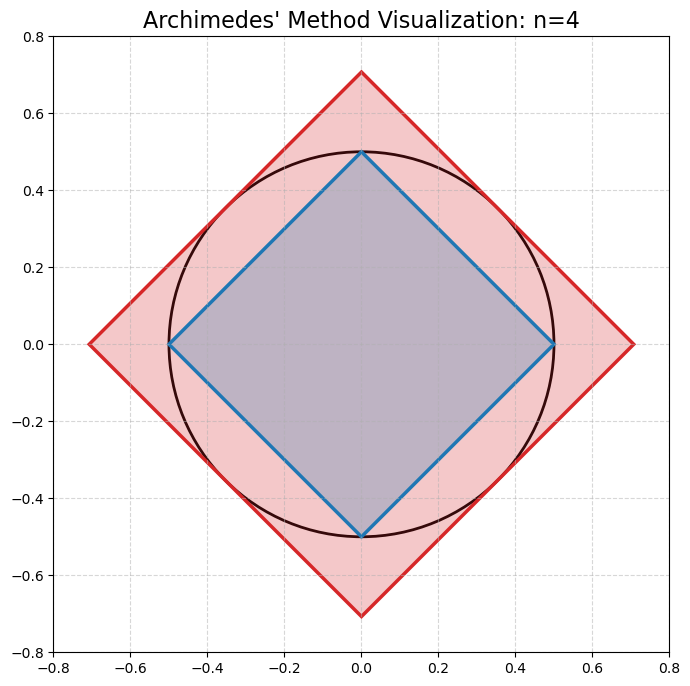

In [18]:
visualize_archimedes_method(4)

$\pi$ is defined to be the circumference of a circle of diameter 1, so we are trying to calculate the perimeter of the central circle in the picture. But circles are curvy, and curvy things are hard to measure precisely. Squares on the other hand are much easier. The perimeter of the inner blue square is surely less than that of the circle, which is in turn clearly less than the perimeter of the outer red square.  $$\text{Perimeter}_{\text{inner}}<\pi<\text{Perimeter}_{\text{outer}}$$
**Inner Square:**

The circle's diameter is the same thing as the small square's diagonal. By the pythagorean theorem, the side length of the small square satifies $s^2+s^2=1^2$, which implies $s={\sqrt{2}\over 2}$. The perimeter of a square is quadruple its side length, so we have shown that $$\sqrt{8}<\pi$$

**Outer Square:**

The large square's side length is the same as the circle's diameter, which is 1. Therefore the outer square has perimeter 4. We now know that $$\sqrt{8}<\pi<4$$
You could whip out a calculator to find that $\sqrt{8}\approx 2.83$, but that would defeat the point! The calculator would probably have a special button for $\pi$, which would make Archimedes too jealous. The calculator's $\pi$ button would be much more accurate than our current approximation. Nevertheless, it would still cut off $\pi$ after a fixed number of decimal places, meaning it is still only an approximation. What if we wanted an wanted to know $\pi$ to even higher accuracy? We don't just want to know what the value of $\pi$ is, we want to know *why* the value of $\pi$ is what is. But I'm getting ahead of myself.

We haven't calculated $\sqrt{8}$, but we can calculate $2.5^2=6.25$ by hand. Then we at least know that $\sqrt{6.25}<\sqrt{8}<\sqrt{9}$, so $2.5<\sqrt{8}<3$. Overall, we have shown (without the need of a calculator) that $\pi$ is somewhere in the range $$2.5<\pi<4$$
This is not too impressive! Trying to draw and measure a circle by hand would probably give a more accurate result. We can't even say for sure whether $\pi>3$ or $\pi<3$. Of course Archimedes wasn't satified with this. But he realized that he could use the same idea to get better accuracy by simply increasing the number of sides of the polygons. 

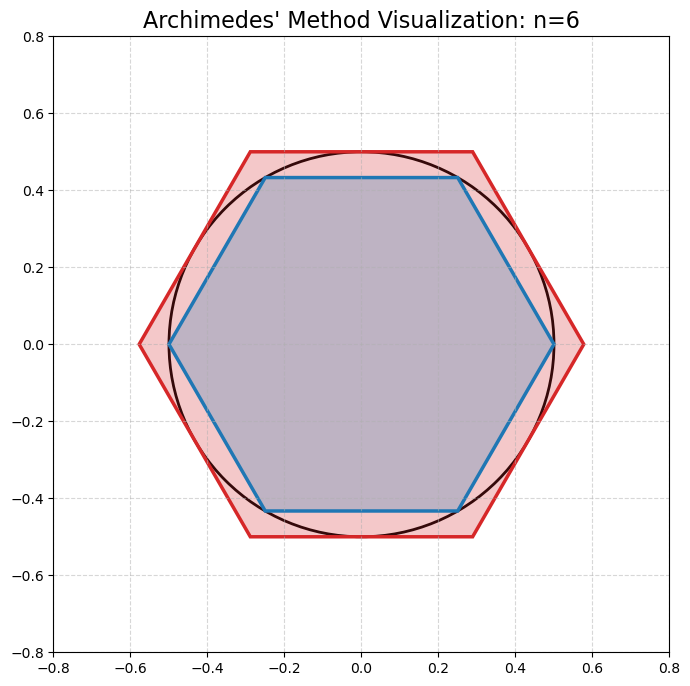

In [19]:
visualize_archimedes_method(6)

If we use hexagons instead of squares, the inner and outer perimeters will end up being closer to $\pi$ simply because there is now less of a gap between the hexagons and circle. The geometry takes a bit longer this time, but hexagons end up improving our estimate to $$3<\pi<\sqrt{12}<3.5$$
So $\pi$ is greater than 3 after all! Thank goodness. 

But we can do better by increasing the number of sides even more. In fact, there is no limit to how good our approximation can get! We can get an extraordinarily good approximation of $\pi$ so long as we are willing and able to do the geometry involved in calculating the side length of a 1000-sided polygon inscribed in a circle of radius $\frac{1}{2}$. 

In [20]:
interact(
    visualize_archimedes_method, 
    n=widgets.IntSlider(
        min=3, 
        max=12, 
        step=1, 
        value=4, 
        description='Sides (n):',
        continuous_update=False # Waits until he releases the slider to re-draw
    ), 
    show_text=widgets.Checkbox(
        value=True, 
        description='Show Error Bounds'
    )
);

interactive(children=(IntSlider(value=4, continuous_update=False, description='Sides (n):', max=12, min=3), Ch…

However, if we continue to put ourselves in Archemede's shoes by refusing to use a calculator, the geometry can get quite tedious. Archemedes himself only went to 96 sides, which provided the best known approximation at the time $$\frac{223}{71}<\pi<\frac{22}{7}$$

Keep in mind that those fractions are themselves approximations of square roots that come from doing good ol' fashioned geometry (Pythagorean Theorem). 

Remember before how we got $\sqrt{8}<\pi$? We approximated $\frac{5}{2}<\sqrt{8}$ by hand, which implied that $\frac{5}{2}<\pi$. Well it turns out that the true values you get from using 96-sided polygons happens to be

$$48\sqrt{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}~ < ~\pi ~< ~96\sqrt{\frac{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}{2+\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}}$$
You can understand why Achemedes stopped increasing the polygon sides after calculating *by hand* that $~~~~\frac{223}{71}<48\sqrt{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}~~~~~~$ and $~~~~~~\frac{22}{7}<96\sqrt{\frac{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}{2+\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}}$.

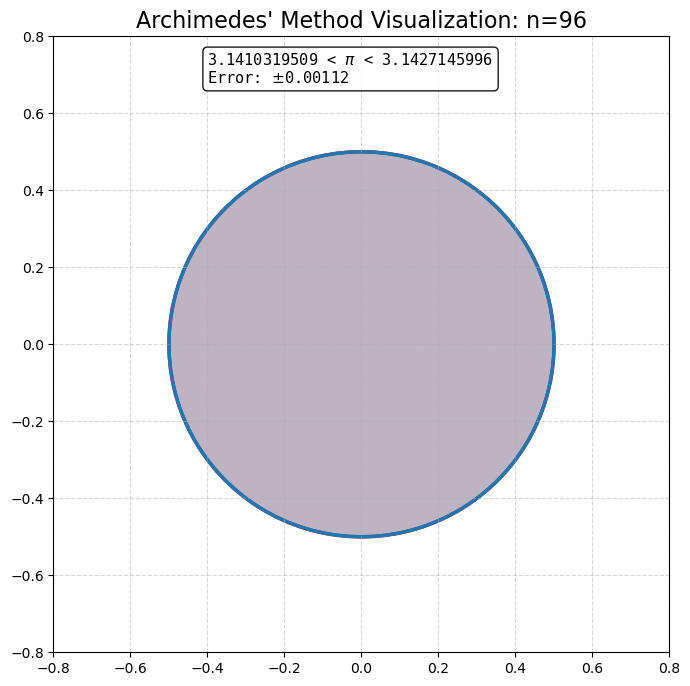

In [21]:
visualize_archimedes_method(96, show_text=True)

At this point, we can't even see the difference between a 96 sided polygon and a circle! And yet, we still only know $\pi$ to 2 decimal places! Amazing how much work went into figuring out that $\pi\approx 3.14\ldots$

Okay, so how can we go further? For an $n$-sided polygon inscribed in a circle, the picture looks like this:

![ngon](https://i.imgur.com/dL5u74P.png)

There are $n$ sides, each of length $\sin\left(\frac{\pi}{n}\right)$, so the total perimeter of the inside polygon is $n\sin\left(\frac{\pi}{n}\right)$. A similar picture shows that the outer perimeter is $n\tan\left(\frac{\pi}{n}\right)\,$. So Archemedes' approach for an $n$-sided polygon gives us the following approximation for $\pi$: $$n\sin\left(\frac{\pi}{n}\right)<\pi<n\tan\left(\frac{\pi}{n}\right)$$ Try plugging in $n=4$ to check against our first square example if you don't believe me!  

It seems like the problem is now harder because we need to compute sine and tangent of $\frac{\pi}{n}$ for a large value of $n$. How can we do this without first knowing what the value of $\pi$ is? Isn't this circular logic? (pun intended) 

Luckily, we can figure out certain values of $\sin\left(\frac{\pi}{n}\right)$ and $\tan\left(\frac{\pi}{n}\right)$ for a few values of $n$ without even knowing what $\pi$ itself is. $\frac{\pi}{2}$ radians is a right angle, so $\sin\left(\frac{\pi}{2}\right)=1\$. Now that we know one angle, we can get half the angle using the trigonometric identities $$\sin\left(\frac{x}{2}\right)=\sqrt{\frac{1-\cos x}{2}}$$ $$\cos\left(\frac{x}{2}\right)=\sqrt{\frac{1+\cos x}{2}}$$

If we keep halfing over and over, we can find the exact values of $2^n\sin\left(\frac{\pi}{2^n}\right)$ for higher and higher powers of 2. 
$$\begin{aligned}2\sin\left(\frac{\pi}{2}\right)&=2
\\
4\sin\left(\frac{\pi}{4}\right)&=2\sqrt{2}
\\
8\sin\left(\frac{\pi}{8}\right)&=4\left(2-\sqrt{2}\right)
\\
16\sin\left(\frac{\pi}{16}\right)&=8\left(2-\sqrt{2+\sqrt{2}}\right)
\\
32\sin\left(\frac{\pi}{32}\right)&=16\left(2-\sqrt{2+\sqrt{2+\sqrt{2}}}\right)
\\
2^n\sin\left(\frac{\pi}{2^{n}}\right)&=2^{n-1}\left(2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{\cdots \overline{~\cdots \overline{+ \sqrt{2}}}}}}}\right)
\end{aligned}
$$

In 1615, Ludolph van Ceulen took this to its logical conclusion. He devoted much of his life calculating all the way to $\pi\approx 2^{62}\sin\left(\frac{\pi}{2^{62}}\right)$. In other words, he found the perimeter of a 4611686018427387904 sided polygon. By hand!! In the end, this gave an approximation of $\pi$ accurate to 32 decimal places, which was engraved on his tombstone. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def count_correct_decimals(approx):
    """Helper function to count matching decimal places with true Pi."""
    pi_str = f"{np.pi:.12f}".split('.')[1]
    approx_str = f"{approx:.12f}".split('.')[1]
    
    matches = 0
    for p, a in zip(pi_str, approx_str):
        if p == a:
            matches += 1
        else:
            break
    return matches

def visualize_powers_of_2_bounds(n_val):
    # 1. Define the continuous domain for the exponent n
    # We use a linear space from n=2 to n=35
    x = np.linspace(2, 35, 1000)
    
    # Calculate N as 2^x (using 2.0 ensures it is a float array, preventing integer overflow)
    N_array = 2.0**x
    y_lower = N_array * np.sin(np.pi / N_array)
    y_upper = N_array * np.tan(np.pi / N_array)
    
    # 2. Calculate the specific values for the current slider 'n'
    N_val = 2.0**n_val
    current_lower = N_val * np.sin(np.pi / N_val)
    current_upper = N_val * np.tan(np.pi / N_val)
    
    # 3. Calculate correct digits
    lower_digits = count_correct_decimals(current_lower)
    upper_digits = count_correct_decimals(current_upper)

    # 4. Build the Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(x, y_lower, color='blue', linewidth=2, label=r'$2^n \sin(\pi/2^n)$ (Inscribed)')
    ax.plot(x, y_upper, color='red', linewidth=2, label=r'$2^n \tan(\pi/2^n)$ (Circumscribed)')
    ax.axhline(np.pi, color='green', linestyle='dashed', linewidth=2, label=r'Exact $\pi$')
    
    ax.fill_between(x, y_lower, y_upper, color='purple', alpha=0.15, label='Bounded Region')
    
    # Highlight the current slider value
    ax.axvline(n_val, color='black', linestyle=':', alpha=0.5)
    ax.scatter([n_val, n_val], [current_lower, current_upper], color='black', s=50, zorder=5)
    
    # 5. Format the Graph with Dynamic Zoom
    ax.set_xlim(2, 35)
    
    # Dynamic zoom to ensure the bounds never visually merge on screen
    gap = current_upper - current_lower
    padding = max(gap, 1e-13) # Tiny minimum padding
    ax.set_ylim(np.pi - padding * 1.5, np.pi + padding * 1.5)
    
    ax.set_xlabel("Power of 2 (n)", fontsize=12)
    ax.set_ylabel("Approximation Value", fontsize=12)
    
    # 6. Dynamic Title showing both n and the total number of sides
    title_text = (
        f"Number of Sides: 2^{n_val} = {int(N_val):,})\n"
        f"Lower Bound: {current_lower:.12f} ({lower_digits} correct decimals)\n"
        f"Upper Bound: {current_upper:.12f} ({upper_digits} correct decimals)"
    )
    plt.title(title_text, fontsize=14, pad=15)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.4, linestyle="--")
    
    plt.show()

# 7. Bind to an Integer Slider
interact(
    visualize_powers_of_2_bounds,
    n_val=widgets.IntSlider(
        min=2, max=32, step=1, value=4, 
        description='Power (n):', continuous_update=False
    )
);

interactive(children=(IntSlider(value=4, continuous_update=False, description='Power (n):', max=32, min=2), Ou…

Notice how it seems to cap out at 12 decimals of accuracy? That's because we hit the precision limit of 64 bit floating point numbers, which is the default for how the computer evaluates $\sin(x)$ and $\tan(x)$ in the first place. It's incredible that Ludolph van Ceulen calculated $\pi$ more precisely by hand in 1615 than computers can today using the standard of 64 bit floating point numbers. If we want more digits of $\pi$, we're going to have to devote more computer space to memorizing all those digits! 

Another way to get more digits of $\pi$ is to change methods entirely. Instead of calculating the perimeter of polygons, let's look at some other formulae for $\pi$.

## Finding $\pi$ as Area

Instead of using a perimeter to estimate $\pi$, we can use an area. Since the area of a circle is $\pi r^2$, this means that $\pi$ is the area of a circle of radius 1. We can approximate the area by using rectangles. The smaller we make the rectangles, the better the approximation. In addition to the circle, there's also lots of other cool shapes that have area $\pi$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def count_correct_decimals(approx):
    """Helper function to count matching decimal places with true Pi."""
    pi_str = f"{np.pi:.15f}".split('.')[1]
    approx_str = f"{approx:.15f}".split('.')[1]
    matches = 0
    for p, a in zip(pi_str, approx_str):
        if p == a:
            matches += 1
        else:
            break
    return matches

def visualize_integration(formula, N_val):
    N = max(int(N_val), 1)
    
    fig, (ax_plot, ax_text) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2.5, 1]})
    
    # === ALGORITHM ROUTING ===
    
    if formula == 'Semicircle Area':
        a, b = -1.0, 1.0
        x_cont = np.linspace(a, b, 1000)
        y_cont = np.sqrt(1 - x_cont**2)
        
        dx = (b - a) / N
        x_mid = np.linspace(a + dx/2, b - dx/2, N)
        y_mid = np.sqrt(1 - x_mid**2)
        
        integral_approx = np.sum(y_mid) * dx
        pi_approx = 2 * integral_approx
        
        original_latex = r"$\pi = 2 \int_{-1}^{1} \sqrt{1-x^2} dx$"
        calc_latex = rf"$\pi \approx 2 \sum_{{i=1}}^{{{N}}} f(x_i^*)\Delta x$"
        theme_color = 'blue'
        
    elif formula == 'Gaussian Integral':
        # Bound infinity to [-8, 8]
        a, b = -8.0, 8.0
        x_cont = np.linspace(-4, 4, 1000) # Only plot the visible center
        y_cont = np.exp(-x_cont**2)
        
        dx = (b - a) / N
        x_mid = np.linspace(a + dx/2, b - dx/2, N)
        y_mid = np.exp(-x_mid**2)
        
        integral_approx = np.sum(y_mid) * dx
        pi_approx = integral_approx**2  
        
        original_latex = r"$\pi = \left( \int_{-\infty}^{\infty} e^{-x^2} dx \right)^2$"
        calc_latex = rf"$\pi \approx \left( \sum_{{i=1}}^{{{N}}} f(x_i^*)\Delta x \right)^2$"
        theme_color = 'purple'

    elif formula == 'Arctangent Integral':
        # Bounded domain [0, 1]
        a, b = 0.0, 1.0
        x_cont = np.linspace(a, b, 1000)
        y_cont = 4.0 / (1.0 + x_cont**2)
        
        dx = (b - a) / N
        x_mid = np.linspace(a + dx/2, b - dx/2, N)
        y_mid = 4.0 / (1.0 + x_mid**2)
        
        integral_approx = np.sum(y_mid) * dx
        pi_approx = integral_approx
        
        original_latex = r"$\pi = 4 \int_{0}^{1} \frac{1}{1+x^2} dx$"
        calc_latex = rf"$\pi \approx \sum_{{i=1}}^{{{N}}} f(x_i^*)\Delta x$"
        theme_color = 'green'

    elif formula == 'Dirichlet (Sinc) Integral':
        # Bound infinity to [-100, 100] for computation
        a, b = -100.0, 100.0
        x_cont = np.linspace(-20, 20, 1000) # Only plot the visible center waves
        # Handle the x=0 division safely
        y_cont = np.divide(np.sin(x_cont), x_cont, out=np.ones_like(x_cont), where=x_cont!=0)
        
        dx = (b - a) / N
        x_mid = np.linspace(a + dx/2, b - dx/2, N)
        y_mid = np.divide(np.sin(x_mid), x_mid, out=np.ones_like(x_mid), where=x_mid!=0)
        
        integral_approx = np.sum(y_mid) * dx
        pi_approx = integral_approx
        
        original_latex = r"$\pi = \int_{-\infty}^{\infty} \frac{\sin(x)}{x} dx$"
        calc_latex = rf"$\pi \approx \sum_{{i=1}}^{{{N}}} f(x_i^*)\Delta x$"
        theme_color = 'orange'

    # === GRAPH FORMATTING ===
    
    ax_plot.plot(x_cont, y_cont, color='black', linewidth=2, label='True Function $f(x)$', zorder=3)
    
    # PERFORMANCE TRICK: Draw individual bars if N <= 100.
    if N <= 1000:
        ax_plot.bar(x_mid, y_mid, width=dx, alpha=0.5, color=theme_color, edgecolor='black', align='center', label='Riemann Rectangles', zorder=2)
    else:
        ax_plot.fill_between(x_cont, 0, y_cont, color=theme_color, alpha=0.5, label='Shaded Area', zorder=2)
        
    # Scale axes based on the function
    if formula == 'Semicircle Area':
        ax_plot.set_xlim(-1.1, 1.1)
        ax_plot.set_ylim(0, 1.2)
        ax_plot.set_aspect('equal') 
    elif formula == 'Gaussian Integral':
        ax_plot.set_xlim(-4, 4)
        ax_plot.set_ylim(0, 1.2)
    elif formula == 'Arctangent Integral':
        ax_plot.set_xlim(-0.05, 1.05)
        ax_plot.set_ylim(0, 4.5)
    elif formula == 'Dirichlet (Sinc) Integral':
        ax_plot.set_xlim(-20, 20)
        ax_plot.set_ylim(-0.4, 1.2)
        ax_plot.axhline(0, color='black', linewidth=1, zorder=1) # Emphasize the x-axis for the wave
        
    error = abs(np.pi - pi_approx)
    digits = count_correct_decimals(pi_approx)
    
    ax_plot.set_xlabel("x-axis", fontsize=12)
    ax_plot.set_ylabel("f(x)", fontsize=12)
    
    title_text = f"{calc_latex} = {pi_approx:.15f}\nError: {error:.2e}  |  Correct Decimals: {digits}"
    ax_plot.set_title(title_text, fontsize=15, pad=15)
    ax_plot.legend(loc='upper right')
    ax_plot.grid(True, alpha=0.3, linestyle="--", zorder=0)
    
    # === TEXT PANE FORMATTING ===
    ax_text.axis('off')
    ax_text.text(0.5, 0.65, "Calculus Integral:", fontsize=16, ha='center', va='center', weight='bold')
    ax_text.text(0.5, 0.45, original_latex, fontsize=20, ha='center', va='center', color=theme_color)
    
    plt.tight_layout()
    plt.show()

# === EXPLICIT WIDGET DEFINITIONS ===

dropdown = widgets.Dropdown(
    options=['Semicircle Area', 'Gaussian Integral', 'Arctangent Integral', 'Dirichlet (Sinc) Integral'],
    value='Semicircle Area',
    description='Integral:'
)

slider_rectangles = widgets.FloatLogSlider(
    value=10, 
    base=10, 
    min=0,     
    max=7,      
    step=0.01, 
    description='Rectangles:', 
    continuous_update=False
)

ui = widgets.VBox([dropdown, slider_rectangles])

out = widgets.interactive_output(
    visualize_integration, 
    {'formula': dropdown, 'N_val': slider_rectangles}
)

display(ui, out)


Output()

Notice how some shapes are better than others for getting more digits faster. Why do you think that is?

## Infinite Series for $\pi$

### Leibniz Formula for $\pi$
One of the oldest formulas for $\pi$ was discovered in 1400 by an Indian mathematician named Madhava of Sangamagrama. But for some reason we call it the Leibniz formula. It says that 
$$\frac{\pi}{4}=\sum_{n=0}^\infty\frac{(-1)^k}{2k+1}=1-\frac{1}{3}+\frac{1}{5}-\frac{1}{7}+\cdots$$
So we alternate adding and subtracting the reciprocals of all the odd numbers, and if we multiply through by 4 then the result is $\pi$! If we want more decimal places, we just ned to add more terms. Let's try it.

In [107]:
def count_correct_decimals(approx):
    """Counts matching decimal places with true Pi."""
    pi_str = f"{np.pi:.15f}".split('.')[1]
    approx_str = f"{approx:.15f}".split('.')[1]
    matches = 0
    for p, a in zip(pi_str, approx_str):
        if p == a:
            matches += 1
        else:
            break
    return matches

def visualize_leibniz(N_val):
    N = int(N_val)
    
    # 1. Calculate terms efficiently using numpy vectors
    n_array = np.arange(N + 1)
    terms = 4.0 * (-1.0)**n_array / (2.0 * n_array + 1.0)
    running_sum = np.cumsum(terms)
    pi_approx = running_sum[-1]
    
    # 2. Calculate metrics
    error = abs(np.pi - pi_approx)
    digits = count_correct_decimals(pi_approx)
    
    # 3. Build the Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # --- CHROMEBOOK PERFORMANCE TRICK ---
    # Plotting 10 million individual points will crash a browser tab.
    # If N is huge, we downsample the line to 5,000 points. The visual is 
    # identical, but it renders instantly for him.
    if N > 5000:
        indices = np.unique(np.linspace(0, N, 5000, dtype=int))
        plot_n = indices
        plot_sum = running_sum[indices]
        ax.plot(plot_n, plot_sum, color='blue', linewidth=1.5, label='Leibniz Series Sum')
    else:
        ax.plot(n_array, running_sum, color='blue', linewidth=1.5, label='Leibniz Series Sum')
        
    ax.axhline(np.pi, color='green', linestyle='dashed', linewidth=2, label=r'Exact $\pi$')
    
    # 4. Format the Graph with Dynamic Zoom
    ax.set_xlim(0, N if N > 0 else 1)
    
    # Zoom in on the tail end of the graph so the alternating "bounce" is visible
    if N > 10:
        zoom_start = int(N * 0.1) 
        ymin = np.min(running_sum[zoom_start:])
        ymax = np.max(running_sum[zoom_start:])
        pad = max((ymax - ymin) * 0.5, 1e-6)
        ax.set_ylim(ymin - pad, ymax + pad)
        
    ax.set_xlabel("Upper Bound (N)", fontsize=12)
    ax.set_ylabel("Approximation Value", fontsize=12)
    
    # 5. Dynamic LaTeX Title
    # We use nested curly braces so the f-string evaluates them into single braces for LaTeX
    latex_sum = rf"$\pi \approx 4 \sum_{{k=0}}^{{{N}}} \frac{{(-1)^k}}{{2k+1}}$"
    
    title_text = (
        f"{latex_sum} = {pi_approx:.10f}\n"
        f"Error: {error:.2e}  |  Correct Decimals: {digits}"
    )
    
    ax.set_title(title_text, fontsize=16, pad=15)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.4, linestyle="--")
    
    plt.show()

# 6. Bind to a Logarithmic Slider
interact(
    visualize_leibniz,
    N_val=widgets.FloatLogSlider(
        value=10, 
        base=10, 
        min=0,     # 10^0 = 1
        max=7,     # 10^7 = 10,000,000
        step=0.01, 
        description='Upper Bound (N):', 
        continuous_update=False
    )
)
    

interactive(children=(FloatLogSlider(value=10.0, continuous_update=False, description='Upper Bound (N):', max=…

<function __main__.visualize_leibniz(N_val)>

This method is terrible! After adding the first million terms, we still only get $\pi$ accurate to 5 digits. In fact, in order to get $n$ digits of $\pi$, you would need to add together about $10^n$ terms, which could take quite a while. Just because it was the first infinite series discovered doesn't mean it's the most efficient. The problem is that odd numbers are only 2 apart from the next one, so the denominator doesn't get 10 times bigger until you do 10 times more terms.

### The Basel Problem

A little while later in 1734, Leonard Euler proved that $$\frac{\pi^2}{6}=\sum_{n=1}^\infty \frac{1}{n^2}=1+\frac{1}{4}+\frac{1}{9}+\frac{1}{16}+\cdots$$
Let's see how this one compares.

In [63]:
def visualize_zeta2(N_val):
    N = int(N_val)
    if N < 1:
        N = 1
        
    # 1. Calculate terms efficiently
    # k starts at 1 to avoid division by zero
    k_array = np.arange(1, N + 1)
    terms = 1.0 / (k_array**2)
    running_sum = np.cumsum(terms)
    
    # 2. Convert the sum of 1/k^2 into the Pi approximation
    # Since sum ≈ pi^2 / 6, then pi ≈ sqrt(6 * sum)
    pi_approx_array = np.sqrt(6.0 * running_sum)
    pi_final = pi_approx_array[-1]
    
    # 3. Calculate metrics
    error = abs(np.pi - pi_final)
    digits = count_correct_decimals(pi_final)
    
    # 4. Build the Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # --- Performance Downsampling for Large N ---
    if N > 5000:
        indices = np.unique(np.linspace(0, N - 1, 5000, dtype=int))
        plot_k = k_array[indices]
        plot_pi = pi_approx_array[indices]
        ax.plot(plot_k, plot_pi, color='purple', linewidth=2, label=r'Basel Problem ($\zeta(2)$)')
    else:
        ax.plot(k_array, pi_approx_array, color='purple', linewidth=2, label=r'Basel Problem ($\zeta(2)$)')
        
    ax.axhline(np.pi, color='green', linestyle='dashed', linewidth=2, label=r'Exact $\pi$')
    
    # 5. Format the Graph with Dynamic Zoom
    ax.set_xlim(1, N if N > 1 else 2)
    
    # Dynamically zoom the Y-axis to frame the asymptotic curve perfectly
    if N > 10:
        zoom_start = int(N * 0.1)
        ymin = pi_approx_array[zoom_start]
        padding = (np.pi - ymin) * 0.2
        # We set the top limit slightly above Pi so the green line isn't cut off
        ax.set_ylim(ymin, np.pi + padding)
        
    ax.set_xlabel("Upper Bound (N)", fontsize=12)
    ax.set_ylabel("Approximation Value", fontsize=12)
    
    # 6. Dynamic LaTeX Title with nested formatting
    latex_sum = rf"$\pi \approx \sqrt{{6 \sum_{{k=1}}^{{{N}}} \frac{{1}}{{k^2}}}}$"
    
    title_text = (
        f"{latex_sum} = {pi_final:.10f}\n"
        f"Error: {error:.2e}  |  Correct Decimals: {digits}"
    )
    
    ax.set_title(title_text, fontsize=16, pad=15)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.4, linestyle="--")
    
    plt.show()

# 7. Bind to a Logarithmic Slider
interact(
    visualize_zeta2,
    N_val=widgets.FloatLogSlider(
        value=10, 
        base=10, 
        min=0,     # 10^0 = 1
        max=7,     # 10^7 = 10,000,000
        step=0.01, 
        description='Upper Bound (N):', 
        continuous_update=False
    )
)

interactive(children=(FloatLogSlider(value=10.0, continuous_update=False, description='Upper Bound (N):', max=…

<function __main__.visualize_zeta2(N_val)>

Turns out it's actually about the same. Here's some more series that evaluate to $\pi$

$$\begin{aligned} \pi&=\sum_{n=-\infty}^\infty \frac{(-1)^n}{n+1/2}
\\
\pi&= 3+\sum_{n=1}^\infty \frac{(-1)^{n+1}}{n(n+1)(2n+1)}
\\
\pi&=\sum_{n=0}^\infty\frac{8}{(4n+1)(4n+3)}\end{aligned}$$


If we add the first 100 terms of each, can you guess which one will give the most accurate estimate of $\pi$? 
#### Ramanujan and Chudnovski
There are two series that blow all of these away in terms of efficiency. The **Ramanujan series** for $\pi$ is $$\pi = \frac{9801}{2\sqrt{2}}\left({\sum_{k=0}^{\infty} \frac{(4k)!(1103+26390k)}{(k!)^4 396^{4k}}}\right)^{-1}$$
This is so accurate that even just the very first term is accurate to 6 decimals $$\pi\approx \frac{9801}{2206\sqrt{2}}=3.1415927300133055\ldots$$
Even better is the **Chudnovsky series** is $$\pi = \frac{1}{12} \left(\sum_{k=0}^{\infty} \frac{(-1)^k (6k)! (13591409 + 545140134k)}{(3k)!(k!)^3 640320^{3k+3/2}}\right)^{-1}$$
The first term is already accurate to 13 digits!
$$\pi \approx \frac{6640320\sqrt{640320}}{163096908}=3.1415926535897345\ldots$$
And it only gets better from there. Each extra term adds even more correct digits. We can't even graph like before because it would just look like a horizontal line exactly at $\pi$. To see how they perform, we need to plot the error on a logarithmic scale.

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from IPython.display import display
import math
from decimal import Decimal, getcontext

# 1. Set arbitrary precision environment to 100 decimal places
getcontext().prec = 1000
PI_TRUE_STR = '3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117067982148086513282306647093844609550582231725359408128481117450284102701938521105559644622948954930381964428810975665933446128475648233786783165271201909145648566923460348610454326648213393607260249141273724587006606315588174881520920962829254091715364367892590360011330530548820466521384146951941511609433057270365759591953092186117381932611793105118548074462379962749567351885752724891227938183011949129833673362440656643086021394946395224737190702179860943702770539217176293176752384674818467669405132000568127145263560827785771342757789609173637178721468440901224953430146549585371050792279689258923542019956112129021960864034418159813629774771309960518707211349999998372978049951059731732816096318595024459455346908302642522308253344685035261931188171010003137838752886587533208381420617177669147303598253490428755468731159562863882353787593751957781857780532171226806613001927876611195909216420198938095257201065485863278865936153381827968230301952035301852968995773622599413891249721775283479131515574857242454150'
PI_TRUE_DEC = Decimal(PI_TRUE_STR)

def count_correct_decimals(approx):
    """Counts matching decimal places against the 100-digit true Pi."""
    pi_str = PI_TRUE_STR.split('.')[1]
    
    if isinstance(approx, float):
        approx_str = f"{approx:.15f}".split('.')[1]
    else:
        approx_str = str(approx)
        if '.' in approx_str:
            approx_str = approx_str.split('.')[1]
        else:
            return 0
            
    matches = 0
    for p, a in zip(pi_str, approx_str):
        if p == a:
            matches += 1
        else:
            break
    return matches

def visualize_all_series(formula, n_log, n_int):
    # Route to the correct N value based on the formula
    if formula in ['Ramanujan Series', 'Chudnovsky Algorithm']:
        N = int(n_int)
    else:
        N = int(n_log)
        
    if N < 0:
        N = 0
        
    fig, (ax_plot, ax_text) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2.5, 1]})
    
    # === ALGORITHM ROUTING ===
    
    if formula == 'Leibniz Series':
        n_array = np.arange(N + 1)
        terms = 4.0 * (-1.0)**n_array / (2.0 * n_array + 1.0)
        running_sum = np.cumsum(terms)
        pi_approx = running_sum[-1]
        error = abs(np.pi - pi_approx)
        
        plot_x = n_array
        plot_y = running_sum
        
        partial_latex = rf"$\pi \approx 4 \sum_{{k=0}}^{{{N}}} \frac{{(-1)^k}}{{2k+1}}$"
        original_latex = r"$\pi = 4 \sum_{k=0}^{\infty} \frac{(-1)^k}{2k+1}$"
        font_size_latex = 24
        
    elif formula == 'Basel Problem (Zeta 2)':
        N_k = N if N > 0 else 1
        k_array = np.arange(1, N_k + 1)
        terms = 1.0 / (k_array**2)
        running_sum = np.cumsum(terms)
        pi_approx_array = np.sqrt(6.0 * running_sum)
        pi_approx = pi_approx_array[-1]
        error = abs(np.pi - pi_approx)
        
        plot_x = k_array
        plot_y = pi_approx_array
        
        partial_latex = rf"$\pi \approx \sqrt{{6 \sum_{{k=1}}^{{{N_k}}} \frac{{1}}{{k^2}}}}$"
        original_latex = r"$\pi = \sqrt{6 \sum_{k=1}^{\infty} \frac{1}{k^2}}$"
        font_size_latex = 24

    elif formula == 'Ramanujan Series':
        pi_approx_list = []
        sum_val = Decimal(0)
        factor = Decimal(2) * Decimal(2).sqrt() / Decimal(9801)
        
        for k in range(N + 1):
            num = Decimal(math.factorial(4*k)) * Decimal(1103 + 26390*k)
            den = (Decimal(math.factorial(k))**4) * (Decimal(396)**(4*k))
            sum_val += num / den
            
            current_pi = Decimal(1) / (factor * sum_val)
            pi_approx_list.append(current_pi)
            
        pi_approx = pi_approx_list[-1]
        error = abs(PI_TRUE_DEC - pi_approx)
        
        plot_x = np.arange(N + 1)
        plot_y = [float(max(abs(PI_TRUE_DEC - p), Decimal('1e-100'))) for p in pi_approx_list] 
        
        partial_latex = rf"$\pi \approx \frac{{9801}}{{2\sqrt{{2}} \sum_{{k=0}}^{{{N}}} \frac{{(4k)!(1103+26390k)}}{{(k!)^4 396^{{4k}}}}}}$"
        original_latex = r"$\pi = \frac{9801}{2\sqrt{2} \sum_{k=0}^{\infty} \frac{(4k)!(1103+26390k)}{(k!)^4 396^{4k}}}$"
        font_size_latex = 18

    elif formula == 'Chudnovsky Algorithm':
        pi_approx_list = []
        sum_val = Decimal(0)
        
        for k in range(N + 1):
            num = (Decimal(-1)**k) * Decimal(math.factorial(6*k)) * Decimal(13591409 + 545140134*k)
            den = Decimal(math.factorial(3*k)) * (Decimal(math.factorial(k))**3) * (Decimal(640320)**Decimal(3*k + 1.5))
            sum_val += num / den
            
            current_pi = Decimal(1) / (Decimal(12) * sum_val)
            pi_approx_list.append(current_pi)
            
        pi_approx = pi_approx_list[-1]
        error = abs(PI_TRUE_DEC - pi_approx)
        
        plot_x = np.arange(N + 1)
        plot_y = [float(max(abs(PI_TRUE_DEC - p), Decimal('1e-100'))) for p in pi_approx_list]
        
        partial_latex = rf"$\pi \approx \frac{{1}}{{12 \sum_{{k=0}}^{{{N}}} \frac{{(-1)^k (6k)! (13591409 + 545140134k)}}{{(3k)!(k!)^3 640320^{{3k+3/2}}}}}}$"
        original_latex = r"$\pi = \frac{1}{12 \sum_{k=0}^{\infty} \frac{(-1)^k (6k)! (13591409 + 545140134k)}{(3k)!(k!)^3 640320^{3k+3/2}}}$"
        font_size_latex = 16
        
    # === GRAPH FORMATTING ===
    
    x_min = min(plot_x)
    x_max = max(plot_x[-1], x_min + 1)
    ax_plot.set_xlim(x_min, x_max)
    
    # Ensure X-axis only displays integers (removes the weird 0.25, 0.50 ticks)
    ax_plot.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    if formula in ['Ramanujan Series', 'Chudnovsky Algorithm']:
        # LOGARITHMIC ERROR PLOT
        ax_plot.plot(plot_x, plot_y, color='red', linewidth=2, marker='o')
        ax_plot.set_yscale('log')
        
        # Dynamic Y-axis zoom to remove the massive empty space
        ymin = max(min(plot_y), 1e-100)
        ymax = max(plot_y)
        
        # Add dynamic padding so the line is nicely framed
        ax_plot.set_ylim(ymin * 1e-2, ymax * 1e2)
        
        ax_plot.set_ylabel("Absolute Error (Log Scale) |π - Approx|", fontsize=12)
        ax_plot.grid(True, which="both", alpha=0.3, linestyle="--") 
        
    else:
        # LINEAR APPROXIMATION PLOT
        if len(plot_x) > 5000:
            indices = np.unique(np.linspace(0, len(plot_x) - 1, 5000, dtype=int))
            ax_plot.plot(np.array(plot_x)[indices], np.array(plot_y)[indices], color='blue', linewidth=2)
        else:
            ax_plot.plot(plot_x, plot_y, color='blue', linewidth=2)

        ax_plot.axhline(np.pi, color='green', linestyle='dashed', linewidth=2, label=r'Exact $\pi$')
        ax_plot.set_ylabel("Approximation Value", fontsize=12)
        
        # Stops matplotlib from adding a weird +3.1415 scientific offset to the axis
        ax_plot.get_yaxis().get_major_formatter().set_useOffset(False)
        ax_plot.legend(loc='best')
        ax_plot.grid(True, alpha=0.4, linestyle="--")
        
        if len(plot_y) > 10:
            ymin = min(plot_y[-10:])
            ymax = max(plot_y[-10:])
            pad = max((ymax - ymin) * 0.5, 1e-6)
            ax_plot.set_ylim(ymin - pad, max(ymin + pad, np.pi + pad))
    
    digits = count_correct_decimals(pi_approx)        
    ax_plot.set_xlabel("Number of Terms (N)", fontsize=12)
    
    error_str = f"{float(error):.2e}" if error > Decimal('1e-100') else "0.00e+00"
    title_text = f"{partial_latex}\nError: {error_str}  |  Correct Decimals: {digits}"
    ax_plot.set_title(title_text, fontsize=15, pad=15)
    
    # === TEXT PANE FORMATTING ===
    ax_text.axis('off')
    ax_text.text(0.5, 0.65, "Infinite Series Formula:", fontsize=16, ha='center', va='center', weight='bold')
    ax_text.text(0.5, 0.45, original_latex, fontsize=font_size_latex, ha='center', va='center', color='black')
    
    plt.tight_layout()
    plt.show()

# === EXPLICIT WIDGET DEFINITIONS ===

dropdown = widgets.Dropdown(
    options=['Leibniz Series', 'Basel Problem (Zeta 2)', 'Ramanujan Series', 'Chudnovsky Algorithm'],
    value='Leibniz Series',
    description='Algorithm:'
)

slider_log = widgets.FloatLogSlider(
    value=10, base=10, min=0, max=7, step=0.01, 
    description='Terms (N):', continuous_update=False
)

slider_int = widgets.IntSlider(
    value=1, min=0, max=10, step=1, 
    description='Terms (N):', continuous_update=False
)

ui = widgets.VBox([dropdown, slider_log])

def update_ui(change):
    if change['new'] in ['Ramanujan Series', 'Chudnovsky Algorithm']:
        ui.children = (dropdown, slider_int)
    else:
        ui.children = (dropdown, slider_log)

dropdown.observe(update_ui, names='value')

out = widgets.interactive_output(
    visualize_all_series, 
    {'formula': dropdown, 'n_log': slider_log, 'n_int': slider_int}
)

display(ui, out)

Output()

In reality, the Chudnovsky log error continues in a straight line. But the series is too precise for floating points after only 7 terms. Wow! This series has been used to calculate 314 trillion digits of $\pi$ as of December 2025. 

## Generating $\pi$ Randomly

What if we throw darts randomly at square with a circular dartboard? Sometimes we hit the circle and sometimes we miss. If we do this lots of times, we can approximate the area of the dartboard! 

In [54]:
def visualize_n_ball(dimension, samples):
    # 1. Generate random points in the n-dimensional hypercube [-1, 1]^n
    points = np.random.uniform(-1, 1, size=(dimension, samples))
    
    # 2. Calculate distances from the origin
    distances = np.linalg.norm(points, axis=0)
    
    # 3. Determine which points fall inside the n-ball (radius <= 1)
    in_ball_mask = (distances <= 1)
    proportion_in_ball = np.mean(in_ball_mask)
    
    # 4. Calculate Pi estimate
    vol_cube = 2 ** dimension
    vol_ball = proportion_in_ball * vol_cube
    
    if proportion_in_ball > 0:
        pi_est = (vol_ball * gamma(dimension / 2 + 1)) ** (2 / dimension)
    else:
        pi_est = 0.0

    # 5. Build the Visualization
    fig = plt.figure(figsize=(9, 9))
    
    if dimension == 2:
        # --- 2D Plotting Logic ---
        ax = fig.add_subplot(111)
        
        ax.scatter(points[0][~in_ball_mask], points[1][~in_ball_mask], 
                   color='red', alpha=0.5, s=10, label=f'Outside ({int(samples*(1 - proportion_in_ball))})')
        ax.scatter(points[0][in_ball_mask], points[1][in_ball_mask], 
                   color='blue', alpha=0.5, s=10, label=f'Inside ({int(samples*(proportion_in_ball))})')
        
        # Draw the bounding circle (dashed line)
        circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2, linestyle='--')
        ax.add_patch(circle)
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        
    elif dimension == 3:
        # --- 3D Plotting Logic ---
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot points 
        ax.scatter(points[0][~in_ball_mask], points[1][~in_ball_mask], points[2][~in_ball_mask],
                   color='red', alpha=0.2, s=5, label=f'Outside ({int(samples*(1 - proportion_in_ball))})')
        ax.scatter(points[0][in_ball_mask], points[1][in_ball_mask], points[2][in_ball_mask],
                   color='blue', alpha=0.4, s=5, label=f'Inside ({int(samples*(proportion_in_ball))})')
        
        # --- NEW: Draw the transparent sphere ---
        # Generate spherical coordinates
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x_sphere = np.outer(np.cos(u), np.sin(v))
        y_sphere = np.outer(np.sin(u), np.sin(v))
        z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
        
        # Plot the surface with very low alpha (transparency)
        ax.plot_surface(x_sphere, y_sphere, z_sphere, color='cyan', alpha=0.1, 
                        edgecolor='none', shade=True)
        
        # --- NEW: Draw the dashed equator line ---
        theta = np.linspace(0, 2 * np.pi, 100)
        x_eq = np.cos(theta)
        y_eq = np.sin(theta)
        z_eq = np.zeros_like(theta) # Locks the circle flat on the Z=0 plane
        
        ax.plot(x_eq, y_eq, z_eq, linewidth=2, linestyle='dashed', alpha=0.3)
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_zlim(-1.1, 1.1)
        ax.set_box_aspect([1, 1, 1]) 
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        
    # 6. Format Title and Display
    plt.title(f"Random {dimension}D Points \nApproximating π: {pi_est:.5f}", fontsize=15)
    
    # We move the legend outside the plot slightly so it doesn't cover the 3D model
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.show()

# 7. Bind the function to the widgets
interact(
    visualize_n_ball,
    dimension=widgets.Dropdown(
        options=[('2D (Circle)', 2), ('3D (Sphere)', 3)],
        value=3,
        description='Dimension:'
    ),
    samples=widgets.IntSlider(
        min=10, max=5000, step=10, value=200, 
        description='Sample Size:', continuous_update=False
    )
);

interactive(children=(Dropdown(description='Dimension:', index=1, options=(('2D (Circle)', 2), ('3D (Sphere)',…

Basically we are just using randomness to approximate an area (or volume). But there's another way we can approximate $\pi$ using randomness. It turns out that if you take 2 random integers, then the probability that they don't have any common factors is $\frac{6}{\pi^2}$. Not sharing any common factors is called being coprime. So if we generate lots of pairs of integers and count how many are coprime, we can calculate $\pi$

In [33]:
def visualize_coprime_pi(limit, samples):
    # 1. Generate the random pairs
    pairs = np.random.randint(1, limit + 1, size=(2, samples))
    gcds = np.gcd(pairs[0], pairs[1])
    
    # 2. Create a boolean mask: True if coprime, False otherwise
    coprime_mask = (gcds == 1)
    proportion_coprime = np.mean(coprime_mask)
    
    # 3. Calculate the Pi estimate
    if proportion_coprime > 0:
        pi_est = np.sqrt(6 / proportion_coprime)
    else:
        pi_est = 0
        
    # 4. Build the Scatterplot
    plt.figure(figsize=(8, 8))
    
    # Plot non-coprime points (Red)
    plt.scatter(pairs[0][~coprime_mask], pairs[1][~coprime_mask], 
                color='red', alpha=0.6, label='Common Factor (GCD > 1)', s=15)
    
    # Plot coprime points (Blue)
    plt.scatter(pairs[0][coprime_mask], pairs[1][coprime_mask], 
                color='blue', alpha=0.6, label='Coprime (GCD = 1)', s=15)
    
    # 5. Format the graph for maximum readability
    plt.xlim(0, limit + 1)
    plt.ylim(0, limit + 1)
    plt.title(f"Approximating π: {pi_est:.5f}\n(Blue / Total = {proportion_coprime:.4f} ≈ 6/π²)", fontsize=14)
    plt.xlabel("Random Integer X")
    plt.ylabel("Random Integer Y")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    
    # This is the magic command that interact() captures to display the UI
    plt.show()

# 6. Bind the function to explicit widgets
interact(
    visualize_coprime_pi,
    limit=widgets.IntSlider(
        min=10, max=500, step=10, value=50, 
        description='Max Integer:', continuous_update=False
    ),
    samples=widgets.IntSlider(
        min=10, max=1000, step=10, value=100, 
        description='Sample Size:', continuous_update=False
    )
);

interactive(children=(IntSlider(value=50, continuous_update=False, description='Max Integer:', max=500, min=10…